In [1]:
import numpy as np
import tensorflow as tf
import torch
from tensorflow.keras.models import load_model
from tensorflow.keras import Model, layers, Input
from sklearn.preprocessing import LabelEncoder

In [2]:
config = tf.compat.v1.ConfigProto(gpu_options = tf.compat.v1.GPUOptions(per_process_gpu_memory_fraction=1))
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)
tf.compat.v1.keras.backend.set_session(session)
physical_devices = tf.config.experimental.list_physical_devices('GPU')

print("Num GPUs Available: ", len(physical_devices))


Num GPUs Available:  1


In [3]:
# Load pretrained CNN model
pretrained_model = load_model("3DCNN_Avacado__VIS_PCA_model.h5")

pretrained_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 30, 30, 136, 32)   896       
                                                                 
 average_pooling3d (AverageP  (None, 15, 15, 68, 32)   0         
 ooling3D)                                                       
                                                                 
 conv3d_1 (Conv3D)           (None, 13, 13, 66, 64)    55360     
                                                                 
 conv3d_2 (Conv3D)           (None, 11, 11, 64, 128)   221312    
                                                                 
 average_pooling3d_1 (Averag  (None, 5, 5, 32, 128)    0         
 ePooling3D)                                                     
                                                                 
 flatten (Flatten)           (None, 102400)            0

In [4]:
# Load label embeddings
word_embeddings = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\LE_Corpus\Avocado_VIS_Embeddings_Roberta.npy', allow_pickle=True).item()

# Extract embeddings and stack into a 2D array
word_embeddings = np.stack([
    word_embeddings['overripe'],  # No .numpy() needed (already a NumPy array)
    word_embeddings['perfect'], 
    word_embeddings['unripe']
])

# Convert to TensorFlow tensor
word_embeddings_tensor = tf.convert_to_tensor(word_embeddings, dtype=tf.float32)

In [5]:
# Freeze the pretrained layers
for layer in pretrained_model.layers:
    
    layer.trainable = True

# Get the third-last layer's output
second_last_layer_output = pretrained_model.get_layer(index = -4).output  # Shape: (None, 128)

# Define a new trainable dense layer with 1024 neurons
dense_layer = layers.Dense(1024, activation = 'relu', name="trainable_dense_layer")(second_last_layer_output)  # Shape: (None, 1024)

# Normalize the dense layer output and word embeddings tensor
dense_layer_norm = tf.nn.l2_normalize(dense_layer, axis=1)  # Normalize along the last dimension
word_embeddings_norm = tf.nn.l2_normalize(word_embeddings_tensor, axis=1)

# Compute the dot product with word embeddings
#dot_product = tf.matmul(dense_layer, tf.transpose(word_embeddings_tensor))  # Shape: (None, 2)
dot_product = tf.matmul(dense_layer_norm, tf.transpose(word_embeddings_norm))  # Shape: (None, 2)

# Apply softmax activation to get predictions
predictions = layers.Softmax(name="softmax_predictions")(dot_product)

In [6]:
# Define the new model
new_model = Model(inputs=pretrained_model.input, outputs=predictions)

# Compile the model for training
new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_input (InputLayer)   [(None, 32, 32, 138, 1)]  0         
                                                                 
 conv3d (Conv3D)             (None, 30, 30, 136, 32)   896       
                                                                 
 average_pooling3d (AverageP  (None, 15, 15, 68, 32)   0         
 ooling3D)                                                       
                                                                 
 conv3d_1 (Conv3D)           (None, 13, 13, 66, 64)    55360     
                                                                 
 conv3d_2 (Conv3D)           (None, 11, 11, 64, 128)   221312    
                                                                 
 average_pooling3d_1 (Averag  (None, 5, 5, 32, 128)    0         
 ePooling3D)                                                 

In [7]:
data_train = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_VIS_PCA_train.npy', allow_pickle= True)
train_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_Ripeness_VIS_train_labels.npy', allow_pickle= True)

data_val = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_VIS_PCA_val.npy', allow_pickle= True)
val_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_Ripeness_VIS_val_labels.npy', allow_pickle= True)

data_test = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_VIS_PCA_test.npy', allow_pickle= True)
test_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Avacado_VIS\PCA\Avocado_Ripeness_VIS_test_labels.npy', allow_pickle= True)

data_train.shape, train_labels.shape, data_val.shape, val_labels.shape, data_test.shape, test_labels.shape

((910, 32, 32, 138),
 (910,),
 (140, 32, 32, 138),
 (140,),
 (170, 32, 32, 138),
 (170,))

In [8]:
# Compute mean and std from training data (per-channel normalization)
mean = data_train.mean(axis=(0, 1, 2), keepdims=True)
std_dev = data_train.std(axis=(0, 1, 2), keepdims=True)

# Normalize all datasets using training statistics
data_train = (data_train - mean) / std_dev
data_val = (data_val - mean) / std_dev
data_test = (data_test - mean) / std_dev

# Verify shapes
print("Shapes after normalization:")
print("Train:", data_train.shape, "Labels:", train_labels.shape)
print("Val:", data_val.shape, "Labels:", val_labels.shape)
print("Test:", data_test.shape, "Labels:", test_labels.shape)

Shapes after normalization:
Train: (910, 32, 32, 138) Labels: (910,)
Val: (140, 32, 32, 138) Labels: (140,)
Test: (170, 32, 32, 138) Labels: (170,)


In [9]:
le = LabelEncoder()

y_train = le.fit_transform(train_labels)
y_val = le.transform(val_labels)

y_test = le.transform(test_labels)

print("Class mapping:", le.classes_)

Class mapping: ['Overripe' 'Perfect' 'Unripe']


In [10]:
# Add channel dimension to data
data_train = data_train[..., np.newaxis]
data_val = data_val[..., np.newaxis]
data_test = data_test[..., np.newaxis]

data_train.shape, data_val.shape, data_test.shape

((910, 32, 32, 138, 1), (140, 32, 32, 138, 1), (170, 32, 32, 138, 1))

In [11]:
print(np.unique(train_labels))
print(np.unique(y_train))

['Overripe' 'Perfect' 'Unripe']
[0 1 2]


In [12]:
def augment_data(sample, label):
    
    # Ensure both are the same type
    random_scale = tf.cast(tf.random.uniform([], 0.9, 1.1), dtype=sample.dtype)
    sample = sample * random_scale  # Random scale between 0.9 and 1.1
    
    return sample, label

In [13]:
# Convert all data to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((data_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((data_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((data_test, y_test))

# Configure datasets
batch_size = 4

train_dataset = train_dataset.shuffle(buffer_size=100).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [14]:
# Define the callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='3DCNN_Avacado_VIS_PCA_model_Fused.h5',         # Path to save the best model
    monitor='val_accuracy',                       # Metric to monitor
    save_best_only=True,                      # Save only the best model
    save_weights_only=False,                  # Save the entire model (architecture + weights)
    mode='max',                               # Mode 'min' because we want to minimize validation loss
    verbose=1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',                       # Metric to monitor
    patience=15,                              # Number of epochs to wait before stopping
    restore_best_weights=True                 # Restore model weights from the epoch with the best metric
)

# Train the model with the callbacks
history = new_model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/50
228/228 [==============================] - ETA: 0s - loss: 1.0797 - accuracy: 0.3824
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to 3DCNN_Avacado_VIS_PCA_model_Fused.h5
228/228 [==============================] - 15s 45ms/step - loss: 1.0797 - accuracy: 0.3824 - val_loss: 1.0952 - val_accuracy: 0.5000
Epoch 2/50
227/228 [============================>.] - ETA: 0s - loss: 1.0982 - accuracy: 0.4945
Epoch 2: val_accuracy did not improve from 0.50000
228/228 [==============================] - 9s 42ms/step - loss: 1.0982 - accuracy: 0.4945 - val_loss: 1.0958 - val_accuracy: 0.5000
Epoch 3/50
227/228 [============================>.] - ETA: 0s - loss: 1.0973 - accuracy: 0.4956
Epoch 3: val_accuracy did not improve from 0.50000
228/228 [==============================] - 9s 41ms/step - loss: 1.0973 - accuracy: 0.4945 - val_loss: 1.0957 - val_accuracy: 0.5000
Epoch 4/50
228/228 [==============================] - ETA: 0s - loss: 1.0965 - accuracy: 0.4945
Epoch 4: va

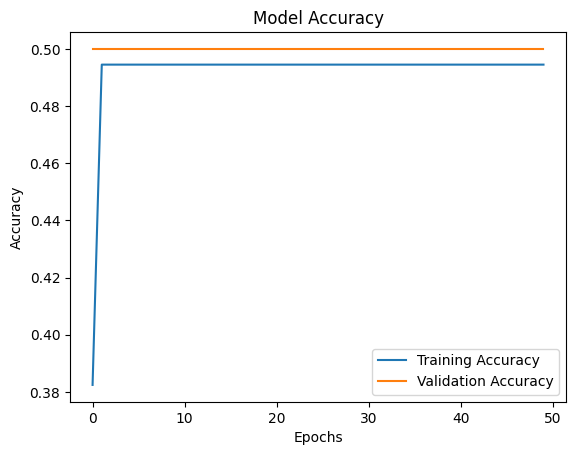

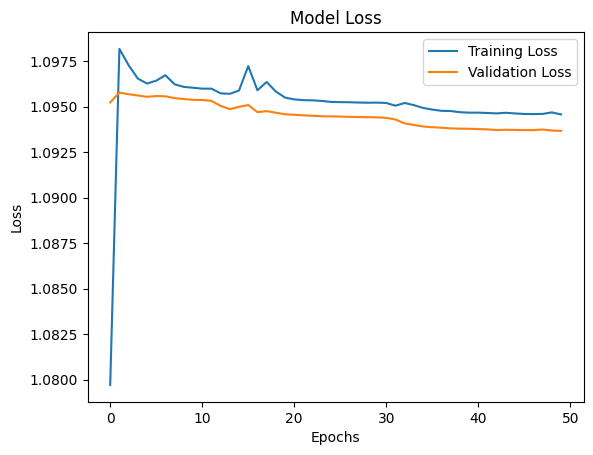

In [15]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
new_model = load_model("3DCNN_Avacado_VIS_PCA_model_Fused.h5")

In [18]:
# Evaluate the model
test_loss, test_accuracy = new_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

43/43 [==============================] - 1s 14ms/step - loss: 1.0959 - accuracy: 0.4706
Test Loss: 1.0959
Test Accuracy: 0.4706


In [20]:
test_predictions_prob = new_model.predict(test_dataset)
test_predictions = np.argmax(test_predictions_prob, axis=1)

43/43 [==============================] - 1s 19ms/step


In [21]:
from sklearn.metrics import classification_report

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, test_predictions, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

    Overripe       0.00      0.00      0.00        50
     Perfect       0.47      1.00      0.64        80
      Unripe       0.00      0.00      0.00        40

    accuracy                           0.47       170
   macro avg       0.16      0.33      0.21       170
weighted avg       0.22      0.47      0.30       170



c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

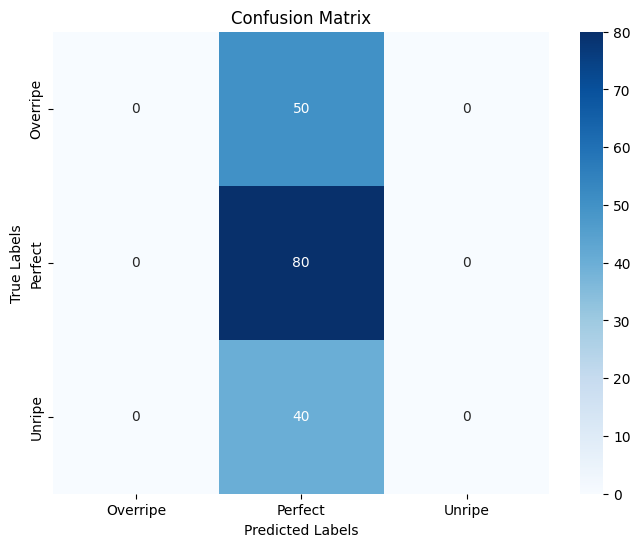

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#confusion matrix
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
